# Phase 4: Fixed Probability Counter Analysis
## Probabilistic Approximate Counting with p=0.25

**Project:** AA Project 3 - Approximate Counting and Frequent Items  
**Author:** João Roldão (113920)  
**Date:** December 2024

---

This notebook implements and evaluates the Fixed Probability Counter on the Porto weather dataset as outlined in `development_plan.md` Phase 4.

**Objectives:**
- Run 100 independent trials with different random seeds
- Compute statistical distributions of estimates
- Validate theoretical properties (unbiased estimator, variance formula)
- Compare against ExactCounter ground truth
- Analyze error scaling with frequency
- Generate comprehensive visualizations

In [1]:
# Import required libraries
import sys
sys.path.append('..')  # Add parent directory to path

from src.algorithms import FixedProbabilityCounter
from src.experiments.fixed_prob_trials import (
    run_multiple_trials,
    aggregate_trial_results,
    calculate_error_metrics,
    calculate_theoretical_variance,
    test_unbiased_estimator
)
from src.utils.data_loader import load_porto_temperatures, get_exact_frequencies
from src.utils.config import (
    RANDOM_SEED,
    FIXED_PROB_P,
    NUM_TRIALS,
    RESULTS_FIXED_PROB_PATH,
    FIGURES_FIXED_PROB_PATH,
    RESULTS_EXACT_PATH
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import time
import tracemalloc
from pathlib import Path
from scipy import stats

# Configure plotting
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

# Ensure output directories exist
Path(RESULTS_FIXED_PROB_PATH).mkdir(parents=True, exist_ok=True)
Path(FIGURES_FIXED_PROB_PATH).mkdir(parents=True, exist_ok=True)

print("✓ Imports successful")
print(f"✓ Configuration: p={FIXED_PROB_P}, trials={NUM_TRIALS}, seed={RANDOM_SEED}")
print(f"✓ Results will be saved to: {RESULTS_FIXED_PROB_PATH}")
print(f"✓ Figures will be saved to: {FIGURES_FIXED_PROB_PATH}")

✓ Imports successful
✓ Configuration: p=0.25, trials=100, seed=113920
✓ Results will be saved to: /home/roldao/Desktop/MEI/AA/project_3/notebooks/../results/fixed_prob
✓ Figures will be saved to: /home/roldao/Desktop/MEI/AA/project_3/notebooks/../results/figures/fixed_prob


## 1. Load Dataset and Ground Truth

In [2]:
# Load temperature stream
temps = load_porto_temperatures(validate=True, verbose=True)

# Load exact counts (ground truth from Phase 3)
exact_counts_df = pd.read_csv(f"{RESULTS_EXACT_PATH}/exact_counts_full_dataset.csv")
exact_counts = dict(zip(exact_counts_df['temperature'], exact_counts_df['count']))

print(f"\n✓ Loaded {len(temps):,} temperature observations")
print(f"✓ Loaded exact counts for {len(exact_counts)} unique temperatures")
print(f"\nGround truth (top 10):")
print(exact_counts_df.head(10))

✓ Loaded Porto weather data from /home/roldao/Desktop/MEI/AA/project_3/notebooks/../data/raw/porto.csv
  • Total observations: 3946
  • Unique temperatures: 30
  • Temperature range: [-1.0°C, 29.0°C]
  • Missing values: 0

✓ Loaded 3,946 temperature observations
✓ Loaded exact counts for 30 unique temperatures

Ground truth (top 10):
   temperature  count
0           16    331
1           17    330
2           15    301
3           19    292
4           18    283
5           13    278
6           14    267
7           20    242
8           12    227
9           21    219


## 2. Run Multiple Trials

**Critical Streaming Methodology:**
- Process the full stream 100 times with different random seeds
- Each trial uses seed: RANDOM_SEED + trial_number
- All trials are independent and reproducible

In [3]:
# Run trials with timing
print("="*60)
print("RUNNING FIXED PROBABILITY COUNTER TRIALS")
print("="*60)

start_time = time.perf_counter()
tracemalloc.start()

trial_results = run_multiple_trials(
    temperatures=temps,
    p=FIXED_PROB_P,
    num_trials=NUM_TRIALS,
    base_seed=RANDOM_SEED,
    verbose=True
)

current_memory, peak_memory = tracemalloc.get_traced_memory()
tracemalloc.stop()
end_time = time.perf_counter()

elapsed_time = end_time - start_time
peak_memory_kb = peak_memory / 1024

print("\n" + "="*60)
print("TRIAL EXECUTION COMPLETE")
print("="*60)
print(f"Total execution time: {elapsed_time:.2f} seconds")
print(f"Peak memory usage: {peak_memory_kb:.2f} KB")
print(f"Total trial runs: {NUM_TRIALS}")
print(f"Results shape: {trial_results.shape}")
print("="*60)

# Display sample results
print("\nSample trial results (first 10 rows):")
print(trial_results.head(10))

RUNNING FIXED PROBABILITY COUNTER TRIALS
Running 100 trials with p=0.25, base_seed=113920
Processing 3946 observations per trial...
  Completed 10/100 trials...
  Completed 20/100 trials...
  Completed 30/100 trials...
  Completed 40/100 trials...
  Completed 50/100 trials...
  Completed 60/100 trials...
  Completed 70/100 trials...
  Completed 80/100 trials...
  Completed 90/100 trials...
  Completed 100/100 trials...
✓ All 100 trials completed

TRIAL EXECUTION COMPLETE
Total execution time: 0.50 seconds
Peak memory usage: 884.80 KB
Total trial runs: 100
Results shape: (3000, 3)

Sample trial results (first 10 rows):
   trial  temperature  estimate
0      0           12     256.0
1      0           11     208.0
2      0           13     264.0
3      0           16     332.0
4      0           14     272.0
5      0           15     300.0
6      0            7     116.0
7      0            6      68.0
8      0           10     200.0
9      0            9     148.0


## 3. Aggregate Results and Calculate Statistics

In [4]:
# Aggregate trial results
aggregated = aggregate_trial_results(trial_results, confidence_level=0.95)

print("="*60)
print("AGGREGATED STATISTICS (per temperature)")
print("="*60)
print(aggregated.head(10))
print("\nColumns:", list(aggregated.columns))

AGGREGATED STATISTICS (per temperature)
   temperature  num_trials  mean_estimate  std_estimate  min_estimate  \
0           -1         100           2.32      2.677554           0.0   
1            0         100           1.96      2.696500           0.0   
2            1         100           6.44      4.015928           0.0   
3            2         100          15.44      6.727480           0.0   
4            3         100          14.16      6.392420           0.0   
5            4         100          28.04      8.668904           8.0   
6            5         100          46.48     12.874279          28.0   
7            6         100          74.88     14.760909          40.0   
8            7         100          90.40     15.392508          60.0   
9            8         100         125.04     20.000970          76.0   

   max_estimate    ci_lower    ci_upper  
0           8.0    1.788715    2.851285  
1           8.0    1.424956    2.495044  
2          16.0    5.643153   

In [5]:
# Calculate error metrics
error_metrics = calculate_error_metrics(aggregated, exact_counts)

print("\n" + "="*60)
print("ERROR METRICS (sorted by frequency)")
print("="*60)
error_metrics_sorted = error_metrics.sort_values('true_count', ascending=False)
print(error_metrics_sorted[[
    'temperature', 'true_count', 'mean_estimate', 
    'std_estimate', 'bias', 'relative_error'
]].head(15))


ERROR METRICS (sorted by frequency)
    temperature  true_count  mean_estimate  std_estimate  bias  relative_error
17           16         331         332.44     32.703850  1.44        0.004350
18           17         330         329.76     35.213955 -0.24        0.000727
16           15         301         298.56     34.603766 -2.44        0.008106
20           19         292         294.28     28.073525  2.28        0.007808
19           18         283         282.68     29.051289 -0.32        0.001131
14           13         278         276.16     28.804713 -1.84        0.006619
15           14         267         266.64     29.179874 -0.36        0.001348
21           20         242         248.16     31.253515  6.16        0.025455
13           12         227         219.88     26.487001 -7.12        0.031366
22           21         219         218.68     25.672719 -0.32        0.001461
12           11         218         214.92     23.694043 -3.08        0.014128
11           10

## 4. Theoretical Variance Validation

In [6]:
# Calculate theoretical variance
theoretical = calculate_theoretical_variance(exact_counts, p=FIXED_PROB_P)

# Merge with empirical results
comparison = error_metrics.merge(
    theoretical[['temperature', 'theoretical_variance', 'theoretical_std']],
    on='temperature'
)

# Compare theoretical vs empirical
comparison['variance_ratio'] = comparison['std_estimate']**2 / comparison['theoretical_variance']

print("="*60)
print("THEORETICAL VS EMPIRICAL VARIANCE COMPARISON")
print("="*60)
print("\nTop 10 temperatures (by frequency):")
print(comparison.sort_values('true_count', ascending=False)[[
    'temperature', 'true_count', 'std_estimate', 'theoretical_std', 'variance_ratio'
]].head(10))

print(f"\nMean variance ratio: {comparison['variance_ratio'].mean():.3f}")
print(f"(Should be close to 1.0 if theory matches practice)")

THEORETICAL VS EMPIRICAL VARIANCE COMPARISON

Top 10 temperatures (by frequency):
    temperature  true_count  std_estimate  theoretical_std  variance_ratio
17           16         331     32.703850        31.511903        1.077081
18           17         330     35.213955        31.464265        1.252548
16           15         301     34.603766        30.049958        1.326047
20           19         292     28.073525        29.597297        0.899684
19           18         283     29.051289        29.137605        0.994084
14           13         278     28.804713        28.879058        0.994858
15           14         267     29.179874        28.301943        1.063003
21           20         242     31.253515        26.944387        1.345430
13           12         227     26.487001        26.095977        1.030193
22           21         219     25.672719        25.632011        1.003179

Mean variance ratio: 1.025
(Should be close to 1.0 if theory matches practice)


## 5. Statistical Hypothesis Testing

### Test H₀: Estimator is Unbiased (mean bias = 0)

In [7]:
# Test unbiased estimator property
unbiased_test = test_unbiased_estimator(error_metrics, alpha=0.05)

print("="*60)
print("UNBIASED ESTIMATOR TEST")
print("="*60)
print(f"Null Hypothesis H₀: mean(bias) = 0")
print(f"Alternative H₁: mean(bias) ≠ 0")
print(f"Significance level α: 0.05")
print("\nResults:")
for key, value in unbiased_test.items():
    if key != 'conclusion':
        print(f"  {key}: {value}")
print("\nConclusion:")
print(f"  {unbiased_test['conclusion']}")
print("="*60)

UNBIASED ESTIMATOR TEST
Null Hypothesis H₀: mean(bias) = 0
Alternative H₁: mean(bias) ≠ 0
Significance level α: 0.05

Results:
  mean_bias: -0.1546666666666673
  std_bias: 2.1304830959719485
  t_statistic: -0.3909467724690676
  p_value: 0.6986940639222827
  is_unbiased: True

Conclusion:
  ✓ Fail to reject H₀ at α=0.050 (p=0.6987). Estimator is unbiased (mean bias=-0.1547).


## 6. Visualizations

### 6.1 Scatter Plot: True Frequency vs Relative Error

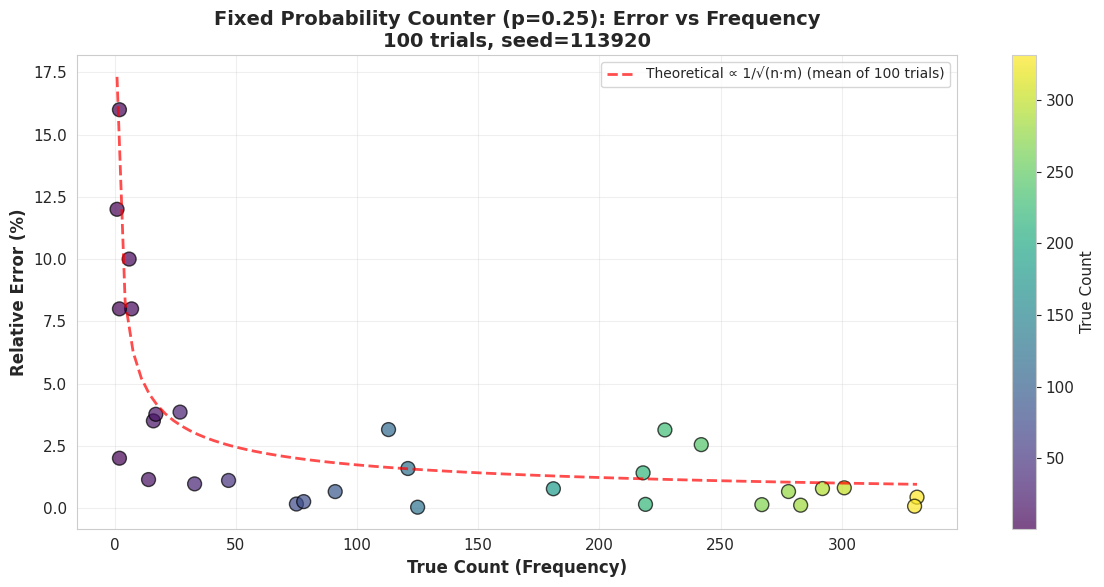

✓ Saved frequency vs error plot


In [8]:
# Frequency vs Relative Error
fig, ax = plt.subplots(figsize=(12, 6))

scatter = ax.scatter(
    error_metrics['true_count'],
    error_metrics['relative_error'] * 100,
    c=error_metrics['true_count'],
    cmap='viridis',
    s=100,
    alpha=0.7,
    edgecolors='black'
)

ax.set_xlabel('True Count (Frequency)', fontsize=12, fontweight='bold')
ax.set_ylabel('Relative Error (%)', fontsize=12, fontweight='bold')
ax.set_title(
    f'Fixed Probability Counter (p={FIXED_PROB_P}): Error vs Frequency\n'
    f'{NUM_TRIALS} trials, seed={RANDOM_SEED}',
    fontsize=14,
    fontweight='bold'
)
ax.grid(True, alpha=0.3)

# Add theoretical error curve - FIX: account for averaging across trials
# Relative error for MEAN of NUM_TRIALS: std(mean) = std(single) / sqrt(NUM_TRIALS)
# std(single) = sqrt((1-p)/p * n), so relative_error = sqrt((1-p)/(p*n)) / sqrt(NUM_TRIALS)
freq_range = np.linspace(1, error_metrics['true_count'].max(), 100)
theoretical_rel_error = np.sqrt((1-FIXED_PROB_P)/(FIXED_PROB_P * freq_range * NUM_TRIALS)) * 100
ax.plot(freq_range, theoretical_rel_error, 'r--', linewidth=2, 
        label=f'Theoretical ∝ 1/√(n·m) (mean of {NUM_TRIALS} trials)', alpha=0.7)

ax.legend(fontsize=10)
plt.colorbar(scatter, ax=ax, label='True Count')
plt.tight_layout()
plt.savefig(f'{FIGURES_FIXED_PROB_PATH}/frequency_vs_error.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved frequency vs error plot")

### 6.2 Box Plots: Estimate Distributions by Frequency Category

/tmp/ipykernel_41983/2515583782.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/roldao/Desktop/MEI/AA/project_3/venv/lib/python3.12/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/roldao/Desktop/MEI/AA/project_3/venv/lib/python3.12/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/roldao/Desktop/MEI/AA/project_3/venv/lib/python3.12/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will

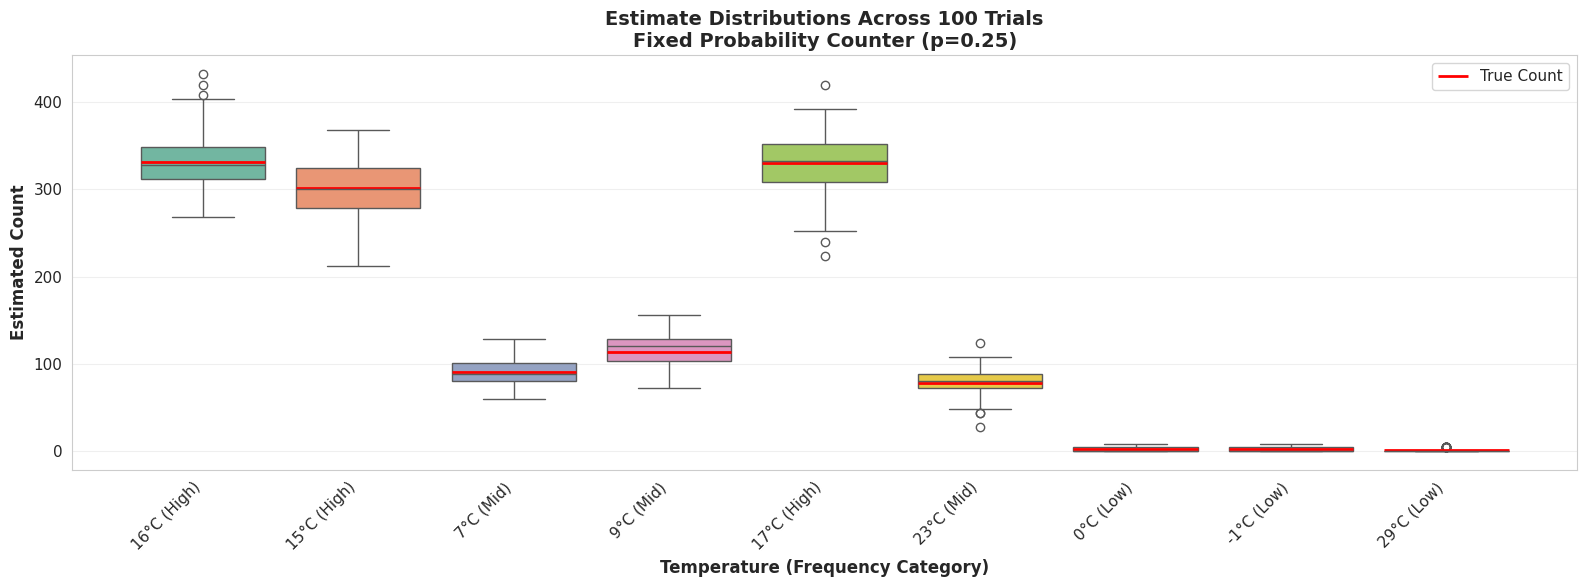

✓ Saved estimate distributions plot


In [14]:
# Select representative temperatures (high, medium, low frequency)
top_temps = error_metrics.nlargest(5, 'true_count')['temperature'].tolist()
mid_temps = error_metrics.sort_values('true_count').iloc[
    len(error_metrics)//2 - 2:len(error_metrics)//2 + 3
]['temperature'].tolist()
low_temps = error_metrics.nsmallest(5, 'true_count')['temperature'].tolist()

selected_temps = top_temps[:3] + mid_temps[:3] + low_temps[:3]

# Filter trial results
selected_data = trial_results[trial_results['temperature'].isin(selected_temps)].copy()

# Add frequency category
def categorize_temp(temp):
    if temp in top_temps:
        return f"{temp}°C (High)"
    elif temp in mid_temps:
        return f"{temp}°C (Mid)"
    else:
        return f"{temp}°C (Low)"

selected_data['category'] = selected_data['temperature'].apply(categorize_temp)

# Box plot
fig, ax = plt.subplots(figsize=(16, 6))
sns.boxplot(
    data=selected_data,
    x='category',
    y='estimate',
    palette='Set2',
    ax=ax
)

# Add true count lines - FIX: match plot order
categories_in_plot_order = selected_data['category'].unique()
category_to_temp = dict(zip(selected_data['category'], selected_data['temperature']))

for i, cat in enumerate(categories_in_plot_order):
    temp = category_to_temp[cat]
    true_count = exact_counts[temp]
    ax.hlines(true_count, i-0.4, i+0.4, colors='red', linewidth=2, 
              label='True Count' if i == 0 else '')

ax.set_xlabel('Temperature (Frequency Category)', fontsize=12, fontweight='bold')
ax.set_ylabel('Estimated Count', fontsize=12, fontweight='bold')
ax.set_title(
    f'Estimate Distributions Across {NUM_TRIALS} Trials\n'
    f'Fixed Probability Counter (p={FIXED_PROB_P})',
    fontsize=14,
    fontweight='bold'
)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{FIGURES_FIXED_PROB_PATH}/estimate_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved estimate distributions plot")

### 6.3 Confidence Intervals Plot

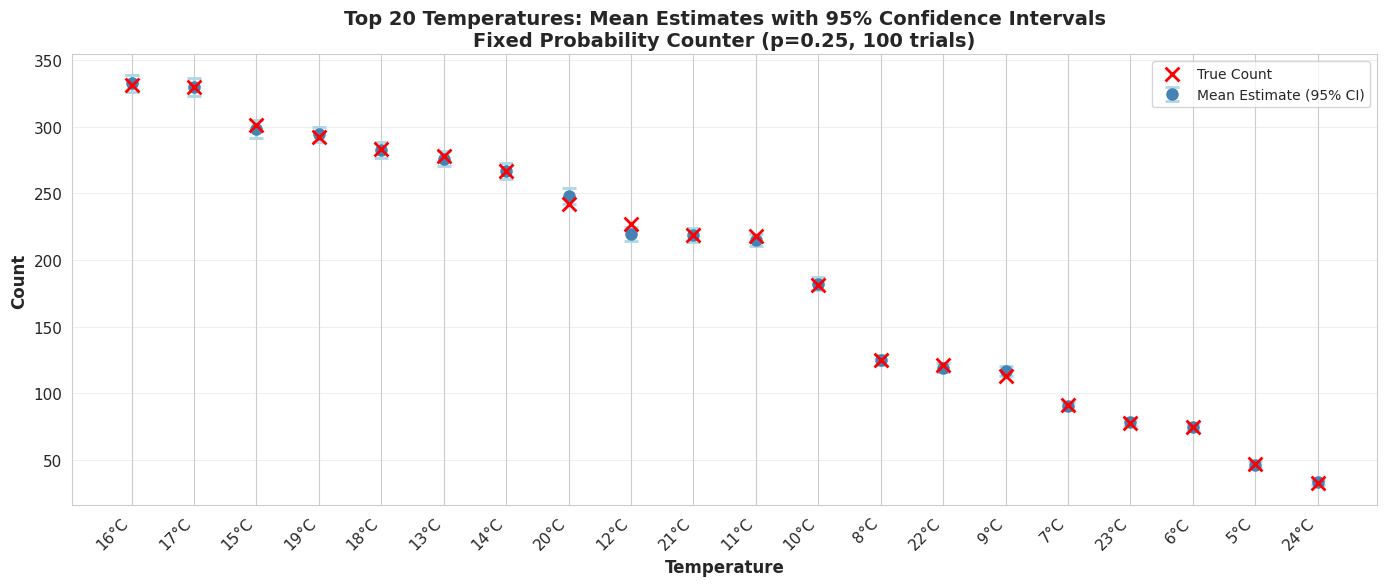

✓ Saved confidence intervals plot


In [10]:
# Plot top 20 with confidence intervals
top_20_errors = error_metrics.nlargest(20, 'true_count')

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(top_20_errors))
yerr = np.array([
    top_20_errors['mean_estimate'] - top_20_errors['ci_lower'],
    top_20_errors['ci_upper'] - top_20_errors['mean_estimate']
])

# Plot estimates with error bars
ax.errorbar(
    x,
    top_20_errors['mean_estimate'],
    yerr=yerr,
    fmt='o',
    markersize=8,
    capsize=5,
    capthick=2,
    label='Mean Estimate (95% CI)',
    color='steelblue',
    ecolor='lightblue',
    elinewidth=2
)

# Plot true counts
ax.scatter(
    x,
    top_20_errors['true_count'],
    s=100,
    color='red',
    marker='x',
    linewidth=2,
    label='True Count',
    zorder=5
)

ax.set_xticks(x)
ax.set_xticklabels([f"{temp}°C" for temp in top_20_errors['temperature']], rotation=45, ha='right')
ax.set_xlabel('Temperature', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_title(
    f'Top 20 Temperatures: Mean Estimates with 95% Confidence Intervals\n'
    f'Fixed Probability Counter (p={FIXED_PROB_P}, {NUM_TRIALS} trials)',
    fontsize=14,
    fontweight='bold'
)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES_FIXED_PROB_PATH}/confidence_intervals.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved confidence intervals plot")

### 6.4 Theoretical vs Empirical Variance

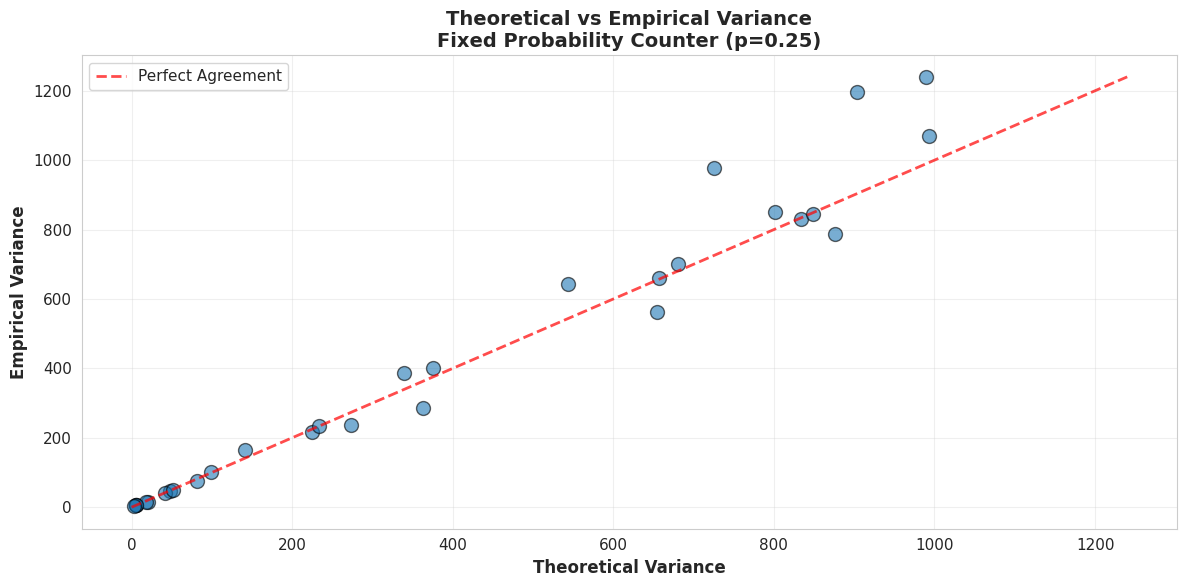

✓ Saved variance comparison plot


In [11]:
# Variance comparison plot
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(
    comparison['theoretical_variance'],
    comparison['std_estimate']**2,
    s=100,
    alpha=0.6,
    edgecolors='black'
)

# Perfect agreement line
max_var = max(comparison['theoretical_variance'].max(), (comparison['std_estimate']**2).max())
ax.plot([0, max_var], [0, max_var], 'r--', linewidth=2, label='Perfect Agreement', alpha=0.7)

ax.set_xlabel('Theoretical Variance', fontsize=12, fontweight='bold')
ax.set_ylabel('Empirical Variance', fontsize=12, fontweight='bold')
ax.set_title(
    f'Theoretical vs Empirical Variance\n'
    f'Fixed Probability Counter (p={FIXED_PROB_P})',
    fontsize=14,
    fontweight='bold'
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES_FIXED_PROB_PATH}/variance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved variance comparison plot")

## 7. Save Results

In [12]:
# Save trial results (pickle for full data preservation)
trial_results_path = f"{RESULTS_FIXED_PROB_PATH}/trial_results_p{int(FIXED_PROB_P*100):02d}_n{NUM_TRIALS}.pkl"
with open(trial_results_path, 'wb') as f:
    pickle.dump(trial_results, f)
print(f"✓ Saved trial results to: {trial_results_path}")

# Save summary statistics (CSV for easy viewing)
summary_path = f"{RESULTS_FIXED_PROB_PATH}/summary_statistics.csv"
error_metrics.to_csv(summary_path, index=False)
print(f"✓ Saved summary statistics to: {summary_path}")

# Save error analysis (JSON)
error_analysis = {
    'configuration': {
        'p': FIXED_PROB_P,
        'num_trials': NUM_TRIALS,
        'random_seed': RANDOM_SEED
    },
    'overall_metrics': {
        'mean_absolute_error': float(error_metrics['absolute_error'].mean()),
        'mean_relative_error': float(error_metrics['relative_error'].mean()),
        'median_relative_error': float(error_metrics['relative_error'].median()),
        'max_relative_error': float(error_metrics['relative_error'].max()),
        'mean_bias': float(error_metrics['bias'].mean()),
        'std_bias': float(error_metrics['bias'].std())
    },
    'unbiased_test': {
        't_statistic': float(unbiased_test['t_statistic']),
        'p_value': float(unbiased_test['p_value']),
        'is_unbiased': bool(unbiased_test['is_unbiased']),
        'conclusion': unbiased_test['conclusion']
    },
    'variance_validation': {
        'mean_variance_ratio': float(comparison['variance_ratio'].mean()),
        'median_variance_ratio': float(comparison['variance_ratio'].median())
    }
}

error_path = f"{RESULTS_FIXED_PROB_PATH}/error_analysis.json"
with open(error_path, 'w') as f:
    json.dump(error_analysis, f, indent=2)
print(f"✓ Saved error analysis to: {error_path}")

# Save performance metrics
performance = {
    'algorithm': 'FixedProbabilityCounter',
    'p': FIXED_PROB_P,
    'num_trials': NUM_TRIALS,
    'total_execution_time_sec': round(elapsed_time, 2),
    'avg_time_per_trial_sec': round(elapsed_time / NUM_TRIALS, 4),
    'peak_memory_kb': round(peak_memory_kb, 2),
    'total_observations_per_trial': len(temps),
    'unique_temperatures': len(exact_counts)
}

perf_path = f"{RESULTS_FIXED_PROB_PATH}/performance_metrics.json"
with open(perf_path, 'w') as f:
    json.dump(performance, f, indent=2)
print(f"✓ Saved performance metrics to: {perf_path}")

✓ Saved trial results to: /home/roldao/Desktop/MEI/AA/project_3/notebooks/../results/fixed_prob/trial_results_p25_n100.pkl
✓ Saved summary statistics to: /home/roldao/Desktop/MEI/AA/project_3/notebooks/../results/fixed_prob/summary_statistics.csv
✓ Saved error analysis to: /home/roldao/Desktop/MEI/AA/project_3/notebooks/../results/fixed_prob/error_analysis.json
✓ Saved performance metrics to: /home/roldao/Desktop/MEI/AA/project_3/notebooks/../results/fixed_prob/performance_metrics.json


## 8. Summary and Key Findings

In [15]:
print("="*60)
print("FIXED PROBABILITY COUNTER ANALYSIS")
print("="*60)
print(f"\n✓ Configuration: p={FIXED_PROB_P}, {NUM_TRIALS} trials, seed={RANDOM_SEED}")
print(f"✓ Processed {len(temps):,} observations per trial")
print(f"✓ Analyzed {len(exact_counts)} unique temperatures")
print(f"\n✓ Performance:")
print(f"  - Total time: {elapsed_time:.2f} sec")
print(f"  - Avg per trial: {elapsed_time/NUM_TRIALS:.4f} sec")
print(f"  - Peak memory: {peak_memory_kb:.2f} KB")
print(f"\n✓ Error Metrics:")
print(f"  - Mean absolute error: {error_analysis['overall_metrics']['mean_absolute_error']:.2f}")
print(f"  - Mean relative error: {error_analysis['overall_metrics']['mean_relative_error']*100:.2f}%")
print(f"  - Median relative error: {error_analysis['overall_metrics']['median_relative_error']*100:.2f}%")
print(f"\n✓ Statistical Validation:")
print(f"  - Unbiased estimator: {'YES' if unbiased_test['is_unbiased'] else 'NO'}")
print(f"  - Mean bias: {error_analysis['overall_metrics']['mean_bias']:.4f}")
print(f"  - p-value: {unbiased_test['p_value']:.4f}")
print(f"  - Variance ratio (empirical/theoretical): {comparison['variance_ratio'].mean():.3f}")
print(f"\n✓ Outputs Generated:")
print(f"  - Trial results pickle")
print(f"  - Summary statistics CSV")
print(f"  - Error analysis JSON")
print(f"  - Performance metrics JSON")
print(f"  - 4 high-resolution figures (300 DPI)")
print(f"\n✓ Ready for Phase 5: Space-Saving Algorithm")
print("="*60)

FIXED PROBABILITY COUNTER ANALYSIS

✓ Configuration: p=0.25, 100 trials, seed=113920
✓ Processed 3,946 observations per trial
✓ Analyzed 30 unique temperatures

✓ Performance:
  - Total time: 0.50 sec
  - Avg per trial: 0.0050 sec
  - Peak memory: 884.80 KB

✓ Error Metrics:
  - Mean absolute error: 1.28
  - Mean relative error: 2.91%
  - Median relative error: 1.12%

✓ Statistical Validation:
  - Unbiased estimator: YES
  - Mean bias: -0.1547
  - p-value: 0.6987
  - Variance ratio (empirical/theoretical): 1.025

✓ Outputs Generated:
  - Trial results pickle
  - Summary statistics CSV
  - Error analysis JSON
  - Performance metrics JSON
  - 4 high-resolution figures (300 DPI)

✓ Ready for Phase 5: Space-Saving Algorithm
